# Week 02 - Camera Calibration

체커보드 이미지로 camera matrix, distortion coefficient, reprojection error를 구하는 노트북.

## Day 1: Pinhole Camera Model 이해

* 목표

    * 카메라가 3D 점을 2D 이미지 평면으로 투영하는 기본 원리를 이해합니다.
    * `intrinsic matrix`가 6D pose pipeline에서 왜 필요한지 이해합니다.

* 할 일

    * pinhole camera model 개념 정리
    * image coordinate, camera coordinate 차이 정리
    * focal length, principal point 의미 정리
    * intrinsic matrix `K` 구조 정리
    * `fx`, `fy`, `cx`, `cy`가 각각 무엇인지 정리

* 산출물

    * `docs/week2_camera_model.md`
    * README에 camera model 요약 추가

## 1. 오늘 배울 개념

오늘은 다음 개념을 다룬다.

- pinhole camera model
- camera coordinate
- image coordinate
- focal length
- principal point
- intrinsic matrix `K`
- 3D point projection
- 6D pose pipeline에서 `K`의 역할

오늘은 아직 camera calibration 코드를 깊게 하지 않는다.  
먼저 `K`가 왜 필요한지 이해한다.


## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 대략 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization

오늘 배우는 pinhole camera model과 intrinsic matrix K는 첫 번째 단계인 Camera Calibration에 해당한다.

특히 K는 이후 다음 단계에서 계속 사용된다.

PnP에서 3D object point를 2D image point와 연결할 때 사용한다.
cv2.projectPoints로 3D 점을 이미지 위에 다시 투영할 때 사용한다.
depth image를 3D point cloud로 복원할 때 사용한다.
reprojection error를 계산할 때 사용한다.

즉, K는 카메라와 이미지 사이의 변환 규칙이다.
```

## 3. Camera Coordinate와 Image Coordinate

카메라 모델을 이해하려면 먼저 두 좌표계를 구분해야 한다.

### Camera Coordinate

Camera coordinate는 카메라 기준의 3D 좌표계이다.

카메라 기준 3D 점은 다음처럼 쓴다.

```text
P_c = [X, Y, Z]
```
각 값의 의미는 다음과 같다.

X: 카메라 기준 좌우 방향 위치
Y: 카메라 기준 위아래 방향 위치
Z: 카메라로부터의 깊이, 즉 depth

6D pose에서 물체 pose를 추정한다는 것은 결국 물체의 3D 점들이 camera frame에서 어디에 있는지 추정하는 것과 연결된다.


### Image Coordinate

Image coordinate는 이미지 위의 2D pixel 좌표계이다.

이미지 점은 다음처럼 쓴다.

p = [u, v]

각 값의 의미는 다음과 같다.

u: 이미지의 가로 방향 pixel 좌표
v: 이미지의 세로 방향 pixel 좌표

OpenCV에서는 일반적으로 이미지의 왼쪽 위가 원점이다.

따라서 P_c = [X, Y, Z]는 3D 공간의 점이고, p = [u, v]는 이미지 위의 2D pixel 점이다.

## 4. Pinhole Camera Model

Pinhole camera model은 카메라를 작은 구멍 하나로 빛이 들어오는 이상적인 모델로 보는 방식이다.

이 모델에서는 3D 점이 카메라 중심을 지나 이미지 평면에 투영된다.

핵심은 다음이다.

```text
3D point in camera frame
P_c = [X, Y, Z]

-> image plane으로 projection

2D point in image
p = [u, v]
```

직관적으로 보면 다음과 같다.

- 물체가 카메라에서 멀어질수록 이미지에서는 작게 보인다.
- `Z`가 커질수록 projected point의 위치 변화는 작아진다.
- 그래서 projection 식에는 `X / Z`, `Y / Z`가 등장한다.

먼저 normalized image coordinate를 계산한다.

```text
x = X / Z
y = Y / Z
```

여기서 `x`, `y`는 아직 pixel 좌표가 아니다.
카메라 중심을 기준으로 한 정규화된 이미지 평면 좌표(normalized image coordinate)이다.

보통 다음처럼 구분한다.
```text
X, Y, Z : 3D camera coordinate = 카메라 앞 3D 공간의 점
x, y    : normalized image coordinate = Z로 나누어서 깊이 효과를 제거한 이상적인 이미지 평면 위 점
u, v    : pixel coordinate = 실제 이미지 배열에서의 pixel 위치
```
coordinate        = 좌표
coordinate system = 좌표계(보통 이건 잘 안 쓰고 기준점이 되는 frame을 잘 씀)
frame             = 어떤 물체나 카메라에 붙어 있는 좌표계

## 5. Intrinsic Matrix K

Intrinsic matrix `K`는 normalized image coordinate를 실제 pixel coordinate로 바꾸는 카메라 내부 파라미터 행렬이다.

`K`는 보통 다음 형태이다.

```text
K = [[fx,  0, cx],
     [ 0, fy, cy],
     [ 0,  0,  1]]
```

각 원소의 의미는 다음과 같다.

- `fx`: x 방향 focal length, pixel 단위
- `fy`: y 방향 focal length, pixel 단위
- `cx`: principal point의 x 좌표
- `cy`: principal point의 y 좌표

`fx`, `fy`는 3D 공간의 방향 변화가 이미지에서 pixel 단위로 얼마나 크게 나타나는지를 결정한다.

`cx`, `cy`는 카메라의 optical center가 이미지 위에서 어디에 위치하는지를 나타낸다.

주의할 점은 `cx`, `cy`를 무조건 이미지의 정확한 중심이라고 생각하면 안 된다는 것이다.  
실제 카메라에서는 optical center가 이미지 중심에서 조금 벗어날 수 있다.

focal length는 한국어로 초점거리이다.

하지만 여기서 중요한 점은, 컴퓨터비전의 intrinsic matrix 안에 들어가는 fx, fy는 보통 pixel 단위의 초점거리라는 점이다.

```text
focal length가 크다
-> 같은 3D 물체가 이미지에서 더 크게 보인다
-> zoom-in처럼 보인다

focal length가 작다
-> 같은 3D 물체가 이미지에서 더 작게 보인다
-> wide-angle처럼 보인다

fx = X 방향 변화가 이미지 u 방향에서 얼마나 크게 보이는지 정하는 값
fy = Y 방향 변화가 이미지 v 방향에서 얼마나 크게 보이는지 정하는 값
```

principal point는 한국어로 보통 주점 또는 주점 좌표라고 합니다.
실무에서는 그냥 principal point라고 많이 부릅니다.

cx, cy가 principal point의 pixel 좌표입니다.

cx = principal point의 x 방향 pixel 좌표
cy = principal point의 y 방향 pixel 좌표

center_x, center_y와 느낌은 비슷하다.

이미지의 기하학적 중심이 아니라, 카메라의 optical axis가 이미지 평면과 만나는 점을 말한다.

optical center는 문맥에 따라 두 가지 의미로 쓰일 때가 있어서 조심해야 합니다.

컴퓨터비전 기하에서는 보통:

optical center = camera center = pinhole = 빛이 모이는 카메라 중심점

즉, 3D 공간에서 카메라의 중심으로, 이미지 위의 pixel이 아니다.

반면 principal point는:

principal point = optical axis가 이미지 평면과 만나는 2D pixel 위치

이다.

관계를 그림처럼 쓰면:

3D 공간:
optical center / camera center
        |
        | optical axis
        v
이미지 평면:
principal point (cx, cy)

그래서 optical center와 principal point는 다릅니다.

optical center: 3D 카메라 중심
principal point: 이미지 위의 2D pixel 좌표

그런데 사람들이 가끔 cx, cy를 optical center라고 부르는 경우도 있습니다.
정확한 표현으로는 cx, cy는 principal point라고 하는 것이 좋습니다.

“초점 맞춰진 픽셀이 중심인가?”라고 생각하셨는데, 그건 아닙니다.
principal point는 초점이 맞은 픽셀이라기보다, 카메라의 정면 방향인 optical axis가 이미지에 찍히는 기준점입니다.

## 6. 3D Point에서 2D Pixel로 가는 식

Camera frame의 3D 점이 다음과 같이 주어졌다고 하자.

```text
P_c = [X, Y, Z]
```

먼저 normalized coordinate를 계산한다.

```text
x = X / Z
y = Y / Z
```

그다음 intrinsic parameter를 이용해 pixel coordinate로 바꾼다.

```text
u = fx * x + cx
v = fy * y + cy
```

즉, 한 번에 쓰면 다음과 같다.

```text
u = fx * X / Z + cx
v = fy * Y / Z + cy
```

이 식은 6D pose estimation에서 매우 중요하다.

왜냐하면 PnP에서는 object frame의 3D 점을 camera frame으로 옮긴 뒤, 이 점들이 이미지 위 어디에 찍히는지를 계산해야 하기 때문이다.

즉, 흐름은 다음과 같다.

```text
Object point P_o
-> pose T_co를 이용해 camera point P_c로 변환
-> intrinsic K를 이용해 image point p로 projection
```

## 7. 간단한 숫자 예제

다음과 같은 3D 점이 camera frame에 있다고 하자.

```text
P_c = [X, Y, Z] = [0.1, 0.05, 1.0]
```

카메라 내부 파라미터는 다음과 같다고 하자.

```text
fx = 600
fy = 600
cx = 320
cy = 240
```

그러면 pixel coordinate는 다음처럼 계산된다.

```text
u = fx * X / Z + cx
u = 600 * 0.1 / 1.0 + 320
u = 380

v = fy * Y / Z + cy
v = 600 * 0.05 / 1.0 + 240
v = 270
```

따라서 이 3D 점은 이미지 위에서 대략 다음 위치에 찍힌다.

```text
p = [u, v] = [380, 270]
```

여기서 중요한 점은 `Z`가 depth 역할을 한다는 것이다.  
같은 `X`, `Y`라도 `Z`가 커지면 `X / Z`, `Y / Z`가 작아져서 이미지 중심에 더 가깝게 보인다.

## 8. Homogeneous Form으로 보기

Projection은 homogeneous coordinate 형태로도 표현할 수 있다.

Camera frame의 3D 점을 다음처럼 쓴다.

```text
P_c = [X, Y, Z]
```

Intrinsic matrix를 곱하면 다음과 같은 형태가 된다.

```text
s * [u, v, 1]^T = K [X, Y, Z]^T
```

여기서 `s`는 scale이고, pinhole camera model에서는 보통 `Z`와 연결된다.

직관적으로는 다음과 같이 이해한다.

```text
K는 camera frame의 3D 점을 image pixel coordinate로 보내는 카메라 내부 규칙이다.
```

주의할 점은 `K`가 pose를 나타내는 행렬은 아니라는 것이다.

- `K`: 카메라 내부 파라미터
- `R`, `t`, `T`: 물체나 좌표계 사이의 pose transform

따라서 `K`와 `T_co`는 서로 다른 종류의 행렬이다.

K는 이미지 한 장 전체에 적용되는 카메라 내부 파라미터이다.

하나의 카메라에서 같은 해상도와 같은 설정으로 찍은 이미지라면 보통 같은 K를 사용한다.

단, 예외는 있다.

이미지를 resize하거나 crop하면 fx, fy, cx, cy도 그에 맞게 조정해야 한다.

예를 들어 이미지를 절반 크기로 줄이면 보통:

fx, fy, cx, cy도 절반으로 조정해야 한다.

## 9. 자주 헷갈리는 점

### 1. K는 pose가 아니다

`K`는 카메라 내부 파라미터이다.  
물체가 어디에 있고 어떻게 회전했는지를 나타내지 않는다.

Pose는 보통 `R`, `t`, `T`로 나타낸다.

### 2. fx, fy는 meter 단위가 아니다

`fx`, `fy`는 보통 pixel 단위로 표현된다.  
따라서 camera matrix `K` 안의 값들은 이미지 좌표계와 연결된다.

### 3. cx, cy는 대충 이미지 중심이 아니다

이론적으로는 principal point가 이미지 중심 근처에 있지만, 실제 calibration 결과에서는 정확히 중심과 다를 수 있다.

### 4. X, Y, Z와 u, v는 다른 좌표계이다

`X, Y, Z`는 3D camera coordinate이다.  
`u, v`는 2D image pixel coordinate이다.

이 둘을 구분하지 못하면 PnP와 depth-to-point-cloud에서 계속 헷갈리게 된다.

### 5. Week 1의 object frame → camera frame 변환과 비슷한가?

네, 느낌은 아주 좋습니다.
하지만 정확히는 단계가 다릅니다.

Week 1에서는:

Object frame의 3D 점
P_o

-> R, t 또는 T_co

Camera frame의 3D 점
P_c

즉, 3D 좌표계에서 다른 3D 좌표계로 옮기는 변환이었습니다.

Week 2에서는:

Camera frame의 3D 점
P_c = [X, Y, Z]

-> projection + K

Image coordinate의 2D 점
p = [u, v]

즉, 3D 점을 2D 이미지 점으로 투영하는 과정입니다.

전체 6D pose 흐름으로 보면 이렇게 연결됩니다.

Object point
P_o = [X_o, Y_o, Z_o]

-> object-to-camera pose T_co

Camera point
P_c = [X_c, Y_c, Z_c]

-> camera intrinsic K

Image point
p = [u, v]

object frame의 3D 점을 먼저 pose T_co로 camera frame의 3D 점으로 바꾸고, 그다음 intrinsic K로 image pixel coordinate에 투영하는 것이다.

즉, K 혼자서 object coordinate를 image coordinate로 바로 바꾸는 것은 아닙니다.
중간에 반드시 object-to-camera pose R, t가 필요합니다.

## 10. 오늘의 핵심 정리

오늘은 pinhole camera model과 intrinsic matrix `K`를 정리했다.

Camera frame의 3D 점 `P_c = [X, Y, Z]`는 먼저 `X / Z`, `Y / Z`를 통해 normalized image coordinate로 투영된다.  
그다음 camera intrinsic matrix `K`의 `fx`, `fy`, `cx`, `cy`를 이용해 pixel coordinate `[u, v]`로 변환된다.

6D pose estimation에서 `K`는 3D object point를 이미지 위 2D point와 연결하는 데 필요하다.  
특히 Week 3의 PnP에서는 `K`와 distortion coefficient를 이용해 object-to-camera pose를 추정한다.

오늘 반드시 기억할 문장은 다음이다.

> Intrinsic matrix `K`는 camera frame의 3D 점을 image pixel coordinate로 투영하기 위한 카메라 내부 파라미터이다.

In [1]:
# Week 2 Day 1: 3D point projection example

import numpy as np

# 3D point in camera frame
X, Y, Z = 0.1, 0.05, 1.0

# Camera intrinsic parameters
fx, fy = 600, 600
cx, cy = 320, 240

# Projection
u = fx * X / Z + cx
v = fy * Y / Z + cy

print("Projected pixel coordinate:")
print("u =", u)
print("v =", v)

# Intrinsic matrix
K = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])

print("\nIntrinsic matrix K:")
print(K)

Projected pixel coordinate:
u = 380.0
v = 270.0

Intrinsic matrix K:
[[600   0 320]
 [  0 600 240]
 [  0   0   1]]


## Day 2: Checkerboard Calibration 데이터 준비

* 목표

    * 카메라 내부 파라미터를 추정하기 위한 체커보드 이미지 데이터를 준비합니다.

* 할 일

    * checkerboard pattern 준비
    * 여러 각도에서 checkerboard 이미지 촬영 또는 샘플 데이터 준비
    * 이미지 파일 경로 정리
    * checkerboard 내부 corner 개수 확인
    * square size 단위 결정

* 산출물

    * `data/calibration/images/`
    * calibration 이미지 목록
    * checkerboard 설정값 기록

# Week 2 Day 2: Checkerboard Calibration 데이터 준비

이번 Day의 목표는 camera calibration에 사용할 checkerboard 이미지 데이터를 준비하는 것이다.

Week 2 Day 1에서는 camera intrinsic matrix `K`가 3D camera point를 2D image coordinate로 투영하는 데 필요하다는 것을 배웠다.

Day 2에서는 이 `K`를 실제로 추정하기 위한 입력 데이터를 준비한다.

오늘의 핵심 질문은 다음이다.

> camera matrix `K`와 distortion coefficients를 추정하려면 어떤 checkerboard 이미지와 설정값이 필요한가?

## 1. 오늘 배울 개념

오늘은 다음 개념을 다룬다.

- checkerboard pattern
- calibration image
- inner corner
- square size
- object points
- image points
- calibration image path
- calibration config

오늘은 아직 `cv2.calibrateCamera`를 실행하지 않는다.  
오늘은 calibration에 들어갈 데이터를 정확히 준비하는 날이다.

## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 대략 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization
```

오늘은 첫 번째 단계인 Camera Calibration을 위한 데이터 준비를 한다.

calibration은 한국어로 보정 또는 교정이라고 한다.

Camera calibration은 카메라가 3D 점을 2D 이미지로 어떻게 투영하는지 설명하는 내부 파라미터 K와 렌즈 왜곡 계수를 추정하는 과정이다.

카메라 문맥에서는 더 정확히 말하면 카메라 파라미터 추정(camera parameter estimation)이다.

즉, “카메라 모델을 사람이 임의로 설정한다”기보다는, 여러 장의 checkerboard 이미지를 보고 camera matrix K, distortion coefficients, rvecs, tvecs값을 추정하는 과정이다.

OpenCV 공식 문서도 camera calibration의 목표를 카메라의 intrinsic/extrinsic properties를 찾고, 그 값으로 undistort하는 것이라고 설명합니다. 또한 camera matrix는 특정 카메라에 고유하며, 같은 카메라로 찍은 다른 이미지에도 재사용할 수 있다고 설명합니다.

Calibration이 잘 되어야 이후 단계에서 다음 값들을 정확히 사용할 수 있다.

```text
camera matrix K
distortion coefficients
```

이 값들은 나중에 다음 곳에서 사용된다.

1. PnP에서 3D object point를 2D image point와 연결할 때 사용된다.
2. 3D axis를 이미지 위에 projection할 때 사용된다.
3. depth image를 point cloud로 복원할 때 사용된다.
4. reprojection error를 계산할 때 사용된다.

즉, 오늘 준비하는 checkerboard 이미지는 나중에 6D pose 전체 파이프라인의 기준 카메라 모델을 만드는 재료이다.

## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 대략 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization
```

오늘은 첫 번째 단계인 Camera Calibration을 위한 데이터 준비를 한다.

Calibration이 잘 되어야 이후 단계에서 다음 값들을 정확히 사용할 수 있다.

```text
camera matrix K
distortion coefficients
```

이 값들은 나중에 다음 곳에서 사용된다.

1. PnP에서 3D object point를 2D image point와 연결할 때 사용된다.
2. 3D axis를 이미지 위에 projection할 때 사용된다.
3. depth image를 point cloud로 복원할 때 사용된다.
4. reprojection error를 계산할 때 사용된다.

즉, 오늘 준비하는 checkerboard 이미지는 나중에 6D pose 전체 파이프라인의 기준 카메라 모델을 만드는 재료이다.

## 3. Checkerboard Calibration이란 무엇인가

Checkerboard calibration은 체커보드의 corner를 이용해 카메라 내부 파라미터를 추정하는 방법이다.

체커보드는 실제 3D 공간에서 각 corner의 상대적인 위치를 알 수 있는 패턴이다.  
이미지에서는 그 corner들이 2D pixel 좌표로 검출된다.

따라서 calibration에서는 다음 대응을 사용한다.

```text
3D object points
-> 실제 체커보드 위 corner의 위치

2D image points
-> 이미지에서 검출된 체커보드 corner의 pixel 좌표
```

카메라는 여러 각도에서 찍힌 checkerboard 이미지를 보고,  
3D object points가 이미지 위 2D image points로 투영되도록 하는 camera matrix `K`와 distortion coefficients를 찾는다.

## 4. Inner Corner란 무엇인가

Checkerboard calibration에서 중요한 것은 square 개수가 아니라 inner corner 개수이다.

Inner corner는 검은색 사각형과 흰색 사각형이 만나는 내부 교차점이다.

예를 들어 체커보드가 다음과 같다고 하자.

```text
가로 square 개수: 10
세로 square 개수: 7
```

그러면 내부 corner 개수는 보통 다음과 같다.

```text
가로 inner corners: 9
세로 inner corners: 6
```

즉, square 개수보다 각 방향으로 1개씩 적다.

OpenCV에서 `pattern_size`를 설정할 때는 보통 다음처럼 내부 corner 개수를 넣는다.

```python
pattern_size = (9, 6)
```

여기서 주의할 점은 이 값이 square 개수가 아니라 내부 corner 개수라는 것이다.

## 5. Square Size란 무엇인가

Square size는 checkerboard 한 칸의 실제 길이이다.

예를 들어 한 칸의 크기가 25 mm라면 다음처럼 기록한다.

```text
square_size = 25.0  # mm
```

또는 meter 단위를 쓴다면 다음처럼 기록한다.

```text
square_size = 0.025  # meter
```

중요한 점은 단위를 반드시 기록해야 한다는 것이다.

Calibration 결과의 translation vector `tvec` 단위는 object points에서 사용한 square size 단위를 따라간다.

예를 들어 object points를 mm로 만들면 `tvec`도 mm 단위로 해석한다.  
object points를 meter로 만들면 `tvec`도 meter 단위로 해석한다.

## 6. 좋은 Calibration 이미지를 찍는 기준

좋은 calibration 이미지는 checkerboard가 다양한 위치와 각도에서 보이는 이미지이다.

다음 조건을 만족하는 이미지를 준비한다.

- checkerboard가 이미지 중앙에만 있지 않도록 한다.
- 이미지 가장자리 근처에도 checkerboard가 보이게 한다.
- checkerboard를 기울여서 다양한 orientation을 만든다.
- 너무 흔들린 이미지는 제외한다.
- 너무 어둡거나 반사가 심한 이미지는 제외한다.
- checkerboard 전체가 이미지 안에 들어오게 한다.
- 최소 10장 이상을 준비한다.
- 가능하면 15장 이상 준비한다.

중요한 것은 같은 자세의 이미지를 많이 찍는 것이 아니라, 다양한 위치와 각도에서 찍는 것이다.

나쁜 예시는 다음과 같다.

```text
- 모든 이미지에서 checkerboard가 중앙에만 있음
- 모든 이미지에서 checkerboard가 정면으로만 있음
- motion blur가 심함
- corner가 일부 잘림
- 조명이 너무 어둡거나 반사가 심함
```

## 7. 오늘 사용할 폴더 구조

이번 프로젝트에서는 calibration 이미지를 다음 경로에 저장한다.

```text
data/
└── calibration/
    ├── images/
    │   ├── calib_001.jpg
    │   ├── calib_002.jpg
    │   ├── calib_003.jpg
    │   └── ...
    └── calibration_config.md
```

오늘의 주요 산출물은 다음이다.

```text
data/calibration/images/
data/calibration/calibration_config.md
```

`images/` 폴더에는 checkerboard 이미지들을 넣는다.

`calibration_config.md`에는 다음 정보를 기록한다.

- checkerboard 내부 corner 개수
- square size
- square size 단위
- 이미지 개수
- 이미지 해상도
- 촬영 장치
- 촬영 조건

## 8. Calibration Config 기록 예시

아래는 `data/calibration/calibration_config.md`에 기록할 내용이다.

```markdown
# Calibration Config

## Camera

- camera name:
- device:
- image resolution:
- image format:

## Checkerboard

- squares per row:
- squares per column:
- inner corners per row:
- inner corners per column:
- OpenCV pattern_size:
- square size:
- square size unit:

## Images

- image directory: `data/calibration/images/`
- number of images:
- filename format: `calib_001.jpg`, `calib_002.jpg`, ...
- capture condition:
- notes:

## Current Setting

```python
pattern_size = (9, 6)
square_size = 25.0  # mm
```

## Notes

- `pattern_size`는 square 개수가 아니라 inner corner 개수이다.
- OpenCV에서는 보통 `(columns, rows)` 순서로 적는다.
- `square_size` 단위는 이후 `tvec` 단위와 연결된다.
```

In [ ]:
from pathlib import Path

# Calibration image directory
image_dir = Path("data/calibration/images")
image_dir.mkdir(parents=True, exist_ok=True)

# Output directory for calibration result
output_dir = Path("outputs/calibration")
output_dir.mkdir(parents=True, exist_ok=True)

print("Created directories:")
print(image_dir)
print(output_dir)

from pathlib import Path

image_dir = Path("data/calibration/images")

image_paths = sorted(
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.png")) +
    list(image_dir.glob("*.jpeg"))
)

print("Number of calibration images:", len(image_paths))

for path in image_paths:
    print(path)
    
import cv2
from pathlib import Path

image_dir = Path("data/calibration/images")

image_paths = sorted(
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.png")) +
    list(image_dir.glob("*.jpeg"))
)

if len(image_paths) == 0:
    print("No calibration images found.")
else:
    for path in image_paths:
        img = cv2.imread(str(path))

        if img is None:
            print("Failed to load:", path)
            continue

        h, w = img.shape[:2]
        print(f"{path.name}: width={w}, height={h}, shape={img.shape}")
        


## Day 3: Checkerboard Corner Detection

* 목표

    * OpenCV로 checkerboard corner를 검출하고, calibration 입력 형식을 이해합니다.

* 할 일

    * `cv2.findChessboardCorners` 사용
    * object points 생성
    * image points 생성
    * 검출된 corner를 이미지 위에 시각화
    * 실패 이미지가 있다면 원인 기록

* 산출물

    * `notebooks/week2_day3_corner_detection.ipynb`
    * corner detection 결과 이미지
    * `experiment_log.md`에 Experiment 002 기록

# Week 2 Day 3: Checkerboard Corner Detection

이번 Day의 목표는 OpenCV를 이용해 calibration 이미지에서 checkerboard inner corner를 검출하는 것이다.

Day 2에서는 calibration에 필요한 설정값을 정리했다.

현재 설정은 다음과 같다.

```python
pattern_size = (10, 7)
square_size = 15.0  # mm
image_size = (3024, 4032)  # width, height
```
오늘의 핵심 질문은 다음이다.

실제 이미지에서 checkerboard corner를 검출하고, calibration에 사용할 object points와 image points를 어떻게 만드는가?

---

## Markdown Cell 2

```markdown
## 1. 오늘 배울 개념

오늘은 다음 개념을 다룬다.

- `cv2.findChessboardCorners`
- `cv2.cornerSubPix`
- `cv2.drawChessboardCorners`
- object points
- image points
- corner detection success / failure
- calibration 입력 데이터 구조

오늘은 아직 `cv2.calibrateCamera`를 실행하지 않는다.  
오늘은 calibration에 들어갈 3D-2D 대응점 데이터를 준비한다.

## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization
```
오늘은 Camera Calibration 단계에서 image points를 추출하는 작업을 한다.

Checkerboard calibration에서는 다음 대응을 사용한다.

object points
= 실제 checkerboard 평면 위 inner corner의 3D 좌표

image points
= 이미지에서 검출된 inner corner의 2D pixel 좌표

이 구조는 Week 3 PnP와 거의 같은 사고방식이다.

PnP에서도 결국 다음 대응을 이용한다.

3D object points
<-> 
2D image points

따라서 오늘은 calibration 실습이지만, 동시에 PnP의 입력 구조를 미리 연습하는 날이다.


## 3. Object Points 만들기

Checkerboard는 평면이라고 가정한다.

따라서 checkerboard 위 corner들의 3D 좌표는 보통 다음처럼 둔다.

```text
Z = 0

현재 checkerboard 설정은 다음과 같다.

pattern_size = (10, 7)
square_size = 15.0  # mm

즉, inner corner는 가로 10개, 세로 7개이다.

Object points는 다음처럼 만들어진다.

[0, 0, 0]
[15, 0, 0]
[30, 0, 0]
...
[0, 15, 0]
[15, 15, 0]
...

여기서 단위는 mm이다.

따라서 이후 calibration 결과로 나오는 translation vector tvec도 mm 단위로 해석한다.

In [17]:
# 1. 기본 설정
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Calibration setting
pattern_size = (10, 7)   # inner corners: columns, rows
square_size = 15.0       # mm

image_dir = Path("/mnt/d/6d-pose-estimation-sprint/data/calibration/images")
result_dir = Path("/mnt/d/6d-pose-estimation-sprint/outputs/week2/corner_detection")
result_dir.mkdir(parents=True, exist_ok=True)

print("pattern_size:", pattern_size)
print("square_size:", square_size, "mm")
print("image_dir:", image_dir)
print("result_dir:", result_dir)

pattern_size: (10, 7)
square_size: 15.0 mm
image_dir: /mnt/d/6d-pose-estimation-sprint/data/calibration/images
result_dir: /mnt/d/6d-pose-estimation-sprint/outputs/week2/corner_detection


In [18]:
# 2. Calibration 이미지 목록 확인
image_paths = sorted(
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.jpeg")) +
    list(image_dir.glob("*.png"))
)

print("Number of images:", len(image_paths))

for path in image_paths:
    print(path)

Number of images: 14
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221616.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221624.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221628.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221636.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221641.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221644.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221646.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221650.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221655.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221704.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221712.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221718.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/image

In [19]:
# 3. Object Points 생성
cols, rows = pattern_size

# objp shape: (rows * cols, 3)
objp = np.zeros((rows * cols, 3), np.float32)

# np.mgrid[0:cols, 0:rows] creates grid coordinates
objp[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2)

# Apply actual square size
objp *= square_size

print("objp shape:", objp.shape)
print("First 10 object points:")
print(objp[:10])

objp shape: (70, 3)
First 10 object points:
[[  0.   0.   0.]
 [ 15.   0.   0.]
 [ 30.   0.   0.]
 [ 45.   0.   0.]
 [ 60.   0.   0.]
 [ 75.   0.   0.]
 [ 90.   0.   0.]
 [105.   0.   0.]
 [120.   0.   0.]
 [135.   0.   0.]]


## 4. Image Points 검출하기

`object points`는 checkerboard 설정으로 직접 만들 수 있다.

하지만 `image points`는 이미지마다 다르므로 실제 이미지에서 검출해야 한다.

OpenCV에서는 다음 함수를 사용한다.

```python
ret, corners = cv2.findChessboardCorners(gray, pattern_size)
```

여기서 의미는 다음과 같다.

gray: grayscale image
pattern_size: inner corner 개수
ret: corner detection 성공 여부
corners: 검출된 2D corner pixel 좌표

검출이 성공하면 corners를 더 정확하게 다듬기 위해 cv2.cornerSubPix를 사용한다.


OpenCV 문서에서도 `findChessboardCorners`는 internal corners를 찾고, `cornerSubPix`는 corner 위치를 sub-pixel 수준으로 더 정확하게 만드는 데 사용된다고 설명합니다. :contentReference[oaicite:1]{index=1}


Test image: 20260602_221616.jpg
Detection success: True
corners shape: (70, 1, 2)


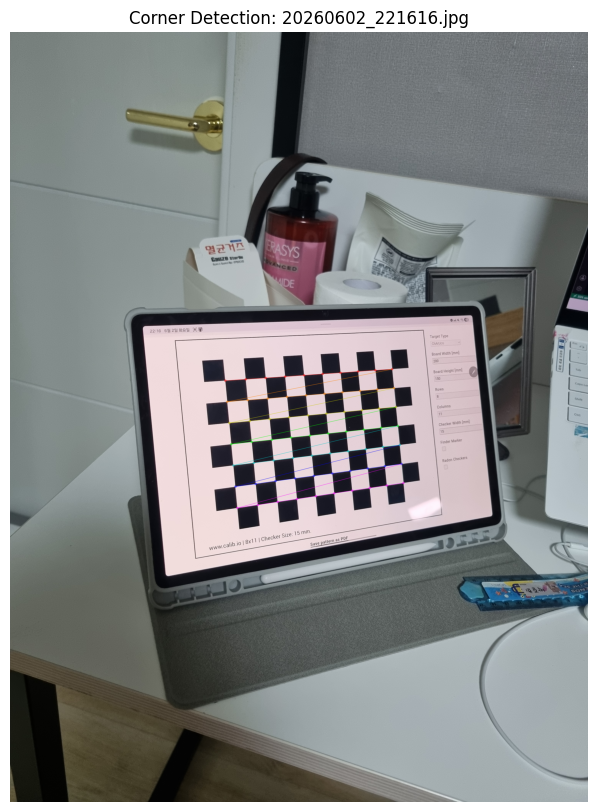

In [20]:
## Code Cell 4: 한 장에서 Corner Detection 확인

# 첫 번째 이미지로 테스트
test_image_path = image_paths[0]

img = cv2.imread(str(test_image_path))
if img is None:
    raise FileNotFoundError(f"Failed to load image: {test_image_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # 흑백으로 변환

ret, corners = cv2.findChessboardCorners(gray, pattern_size)

print("Test image:", test_image_path.name)
print("Detection success:", ret)

if ret:
    print("corners shape:", corners.shape)

    # Refine corner location
    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        30,
        0.001
    )

    corners_refined = cv2.cornerSubPix(
        gray,
        corners,
        winSize=(11, 11),
        zeroZone=(-1, -1),
        criteria=criteria
    )

    img_draw = img.copy()
    cv2.drawChessboardCorners(img_draw, pattern_size, corners_refined, ret)

    # BGR -> RGB for matplotlib
    img_draw_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 10))
    plt.imshow(img_draw_rgb)
    plt.title(f"Corner Detection: {test_image_path.name}")
    plt.axis("off")
    plt.show()
else:
    print("Checkerboard corners were not found.")

## 5. 여러 장 이미지에서 Corner Detection 실행하기

Calibration에서는 여러 장의 이미지에서 검출된 corner를 사용한다.

이미지마다 다음 작업을 반복한다.

```text
1. 이미지 읽기
2. grayscale 변환
3. cv2.findChessboardCorners 실행
4. 성공하면 object points 저장
5. 성공하면 image points 저장
6. corner가 그려진 결과 이미지 저장
7. 실패하면 실패 목록에 기록

In [ ]:
## Code Cell 5: 전체 이미지 Corner Detection

criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

objpoints = []  # 3D points in checkerboard coordinate
imgpoints = []  # 2D points in image pixel coordinate

success_images = []
failed_images = []
rotated_images = []

image_size = None  # (width, height)
for image_path in image_paths:
    img = cv2.imread(str(image_path))

    if img is None:
        failed_images.append((image_path.name, "failed_to_load"))
        continue

    h, w = img.shape[:2]

    # 처음 calibration에서는 landscape 이미지는 제외 버전
    if w > h:
        failed_images.append((image_path.name, "landscape_excluded"))
        continue
    
    # # 로테이션 하는 버전
    # if w > h:
    #     img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    #     rotated_images.append(image_path.name)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape[:2]
    current_image_size = (w, h)

    if image_size is None:
        image_size = current_image_size
    elif image_size != current_image_size:
        failed_images.append((image_path.name, f"image_size_mismatch: {current_image_size}"))
        continue

    ret, corners = cv2.findChessboardCorners(gray, pattern_size)
    
    if ret:
        corners_refined = cv2.cornerSubPix(
            gray,
            corners,
            winSize=(11, 11),
            zeroZone=(-1, -1),
            criteria=criteria
        )

        objpoints.append(objp.copy())
        imgpoints.append(corners_refined)

        success_images.append(image_path.name)

        img_draw = img.copy()
        cv2.drawChessboardCorners(img_draw, pattern_size, corners_refined, ret)

        save_path = result_dir / f"{image_path.stem}_corners.jpg"
        cv2.imwrite(str(save_path), img_draw)

    else:
        failed_images.append((image_path.name, "corners_not_found"))

print("Image size:", image_size)
print("Number of input images:", len(image_paths))
print("Success:", len(success_images))
print("Failed:", len(failed_images))

print("\nSuccess images:")
for name in success_images:
    print("-", name)

print("\nFailed images:")
for name, reason in failed_images:
    print("-", name, "|", reason)

Image size: (3024, 4032)
Number of input images: 14
Success: 11
Failed: 3

Success images:
- 20260602_221616.jpg
- 20260602_221624.jpg
- 20260602_221628.jpg
- 20260602_221636.jpg
- 20260602_221641.jpg
- 20260602_221650.jpg
- 20260602_221655.jpg
- 20260602_221712.jpg
- 20260602_221718.jpg
- 20260602_221724.jpg
- 20260602_221818.jpg

Failed images:
- 20260602_221644.jpg | landscape_excluded
- 20260602_221646.jpg | landscape_excluded
- 20260602_221704.jpg | landscape_excluded


Number of result images: 14


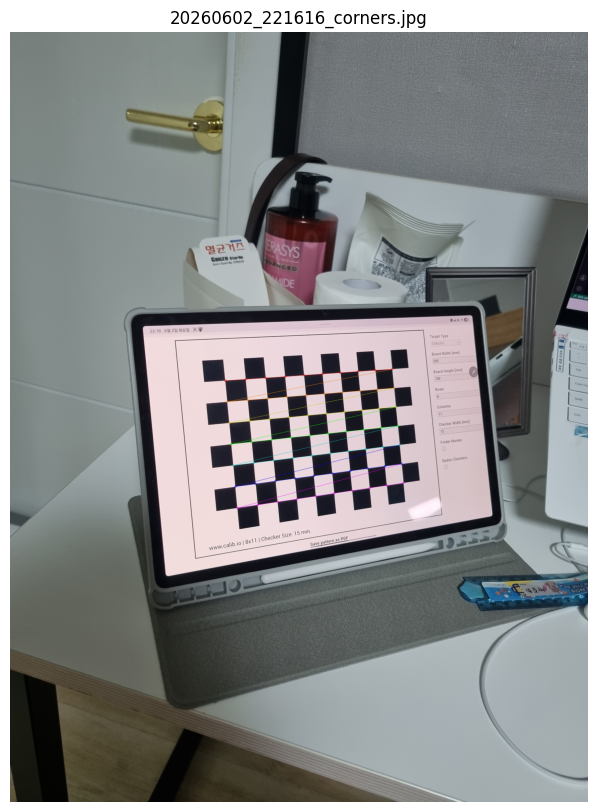

In [24]:
result_paths = sorted(result_dir.glob("*_corners.jpg"))

print("Number of result images:", len(result_paths))

if len(result_paths) > 0:
    result_img = cv2.imread(str(result_paths[0]))
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 10))
    plt.imshow(result_img_rgb)
    plt.title(result_paths[0].name)
    plt.axis("off")
    plt.show()
else:
    print("No result images found.")

## 6. 결과 해석

오늘 저장된 핵심 데이터는 다음이다.

```python
objpoints
imgpoints
image_size
success_images
failed_images
```
각 변수의 의미는 다음과 같다.

objpoints:
여러 이미지에 대해 반복 저장된 checkerboard 3D object points

imgpoints:
각 이미지에서 검출된 checkerboard 2D image points

image_size:
calibration 이미지의 크기
OpenCV calibrateCamera에는 (width, height) 순서로 들어간다

success_images:
corner detection이 성공한 이미지 목록

failed_images:
corner detection이 실패한 이미지 목록

objpoints와 imgpoints는 Day 4의 cv2.calibrateCamera에 그대로 들어간다.


In [25]:
## Code Cell 7: Detection 결과 저장

save_npz_path = result_dir / "corner_detection_data.npz"

np.savez(
    save_npz_path,
    objpoints=np.array(objpoints, dtype=object),
    imgpoints=np.array(imgpoints, dtype=object),
    image_size=np.array(image_size),
    success_images=np.array(success_images),
    failed_images=np.array(failed_images, dtype=object),
    pattern_size=np.array(pattern_size),
    square_size=np.array(square_size)
)

print("Saved:", save_npz_path)

Saved: /mnt/d/6d-pose-estimation-sprint/outputs/week2/corner_detection/corner_detection_data.npz


## 7. Day 3에서 확인해야 하는 것

오늘 확인해야 하는 것은 다음이다.

```text
1. calibration 이미지가 제대로 로드되는가
2. image size가 모두 같은가
3. pattern_size = (10, 7)이 맞는가
4. cv2.findChessboardCorners가 성공하는가
5. corners shape이 (70, 1, 2)로 나오는가
6. corner가 그려진 이미지가 실제 checkerboard와 잘 맞는가
7. 실패 이미지가 있다면 왜 실패했는가

현재 pattern size는 다음과 같다.

pattern_size = (10, 7)

따라서 검출되어야 하는 corner 개수는 다음과 같다.

10 * 7 = 70

검출 성공 시 corners.shape는 보통 다음과 같다.

(70, 1, 2)

---

## Markdown Cell 9: 오늘의 핵심 정리

```markdown
## 8. 오늘의 핵심 정리

오늘은 OpenCV를 이용해 checkerboard calibration 이미지에서 inner corner를 검출했다.

`cv2.findChessboardCorners`는 grayscale image와 `pattern_size`를 입력받아 checkerboard의 2D image points를 찾는다.

Calibration에서 `object points`는 실제 checkerboard 평면 위 inner corner의 3D 좌표이고, `image points`는 이미지에서 검출된 inner corner의 2D pixel 좌표이다.

현재 checkerboard 설정은 다음과 같다.

```python
pattern_size = (10, 7)
square_size = 15.0  # mm

따라서 한 이미지에서 검출되어야 하는 inner corner 수는 70개이다.

검출에 성공한 이미지의 objpoints와 imgpoints는 Day 4의 cv2.calibrateCamera 입력으로 사용된다.

## Day 4: Camera Calibration 수행

* 목표

    * OpenCV camera calibration을 수행하여 camera matrix와 distortion coefficient를 얻습니다.

* 할 일

    * `cv2.calibrateCamera` 실행
    * camera matrix `K` 출력
    * distortion coefficients 출력
    * rotation vector, translation vector 출력 형식 확인
    * calibration 결과 저장

* 산출물

    * `outputs/calibration/camera_matrix.npy`
    * `outputs/calibration/dist_coeffs.npy`
    * calibration 실험 로그

## Day 5: Reprojection Error 계산

* 목표

    * calibration 결과가 얼마나 좋은지 reprojection error로 확인합니다.

* 할 일

    * 3D checkerboard point를 이미지로 다시 projection
    * 검출된 2D corner와 projected point 비교
    * 평균 reprojection error 계산
    * error가 큰 이미지 확인
    * error가 큰 원인 후보 기록

* 산출물

    * reprojection error 수치
    * error 분석 노트
    * `error_log.md` 업데이트

## Day 6: Image Undistortion 확인

* 목표

    * distortion coefficient가 실제 이미지 보정에 어떻게 쓰이는지 확인합니다.

* 할 일

    * `cv2.undistort` 사용
    * 원본 이미지와 undistorted image 비교
    * 왜곡 보정 전후 시각화
    * distortion coefficient의 역할 정리
    * solvePnP에서 distortion coefficient가 왜 필요한지 정리

* 산출물

    * undistortion 전후 비교 이미지
    * `docs/week2_distortion.md`

## Day 7: 정리 및 README 업데이트

* 목표

    * 2주차 내용을 실험노트와 README에 정리합니다.

* 할 일

    * Experiment 002 정리
    * camera matrix 정리
    * distortion coefficient 정리
    * reprojection error 결과 정리
    * README에 Week 2 결과 추가
    * 다음 주 PnP로 넘어갈 준비

* 산출물

    * `experiment_log.md` 업데이트
    * `README.md` 업데이트
    * `project_state.md` 업데이트